**Метою проєкту** було дослідити дані NASA про навколоземні астероїди, визначити потенційно небезпечні об’єкти та побудувати просту модель оцінки ризику на основі дистанції, швидкості, розміру та частоти зближень із Землею.
**Джерело даних** - NASA Near Earth Object API



1.** Завантаження даних**
Завантажуємо дані через ключ. Оскільки дані повертаються з інтервалом в 7 днів, то створюємо дати з кроком 7 днів

In [1]:
import requests
import pandas as pd
from datetime import timedelta

all_data = []
dates = pd.date_range(start='2023-01-01', end='2026-05-16', freq='7D')    # створюємо дати з кроком 7 днів

api_key = "YOUR_API_KEY"                 # api_key = "YOUR_API_KEY" Get your free API key from NASA Open APIs.

for date in dates:                                                   #проходимо циклом для кожної дати

    start_date = date.strftime('%Y-%m-%d')

    end_date = (date + timedelta(days=6)).strftime('%Y-%m-%d')

    url = (
        f"https://api.nasa.gov/neo/rest/v1/feed?"                     #загружаємо дані
        f"start_date={start_date}&end_date={end_date}"
        f"&api_key={api_key}"
    )

    response = requests.get(url)

    data = response.json()

    all_data.append(data)                                             #додаємо дані у список


In [44]:
import json

print(json.dumps(all_data[0], indent=2)[:3000])           #виводимо дані для того, щоб побачити структуру і вибрати колонки

{
  "links": {
    "next": "http://api.nasa.gov/neo/rest/v1/feed?start_date=2023-01-07&end_date=2023-01-13&detailed=false&api_key=mCKpUPESqF7j92DzBq4hkzZ9OLxHBBeFdjfzQ9XA",
    "previous": "http://api.nasa.gov/neo/rest/v1/feed?start_date=2022-12-26&end_date=2023-01-01&detailed=false&api_key=mCKpUPESqF7j92DzBq4hkzZ9OLxHBBeFdjfzQ9XA",
    "self": "http://api.nasa.gov/neo/rest/v1/feed?start_date=2023-01-01&end_date=2023-01-07&detailed=false&api_key=mCKpUPESqF7j92DzBq4hkzZ9OLxHBBeFdjfzQ9XA"
  },
  "element_count": 44,
  "near_earth_objects": {
    "2023-01-01": [
      {
        "links": {
          "self": "http://api.nasa.gov/neo/rest/v1/neo/2453309?api_key=mCKpUPESqF7j92DzBq4hkzZ9OLxHBBeFdjfzQ9XA"
        },
        "id": "2453309",
        "neo_reference_id": "2453309",
        "name": "453309 (2008 VQ4)",
        "nasa_jpl_url": "https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=2453309",
        "absolute_magnitude_h": 19.51,
        "estimated_diameter": {
          "kilometers

2.Для подальшого аналізу було обрано дату, унікальний ідентифікатор астероїда, назву, ознаку потенційної небезпечності, яскравість, швидкість, дистанцію зближення та оцінний розмір. Для консистентності всі показники відстані та розміру приведено до кілометрів.


In [46]:
all_asteroids = []

for week_data in all_data:                                                       #для кожного тижня
    near_objects = week_data['near_earth_objects']

    for date in near_objects:                                                    #для кожної дати
        asteroids = near_objects[date]

        for asteroid in asteroids:                                              #для кожного астероїда
            asteroid_info = {                                                   #обираємо необхідні колонки
                'date': date,
                'neo_reference_id': asteroid['neo_reference_id'],
                'name': asteroid['name'],
                'is_hazardous': asteroid['is_potentially_hazardous_asteroid'],
                'absolute_magnitude': asteroid['absolute_magnitude_h'],
                'relative_velocity_km_h': float(asteroid['close_approach_data'][0]['relative_velocity']['kilometers_per_hour']),
                'miss_distance_km': float(asteroid['close_approach_data'][0]['miss_distance']['kilometers']),
                'estimated_diameter_min_km': float(asteroid['estimated_diameter']['kilometers']['estimated_diameter_min']),
                'estimated_diameter_max_km': float(asteroid['estimated_diameter']['kilometers']['estimated_diameter_max'])
            }

            all_asteroids.append(asteroid_info)

df = pd.DataFrame(all_asteroids)
df.head()


,date,neo_reference_id,name,is_hazardous,absolute_magnitude,relative_velocity_km_h,miss_distance_km,estimated_diameter_min_km,estimated_diameter_max_km
0,2023-01-01,2453309,453309 (2008 VQ4),False,19.51,20959.820766,3.956596e+07,0.333085,0.744801
1,2023-01-01,3683468,(2014 QR295),False,18.39,58249.689663,3.933082e+07,0.557898,1.247498
2,2023-01-01,3703782,(2015 AE45),False,25.30,24703.743910,8.526777e+06,0.023150,0.051765
3,2023-01-01,3720918,(2015 LJ),False,24.70,25881.197586,6.497596e+07,0.030518,0.068240
4,2023-01-01,3767936,(2017 BQ93),True,20.60,86987.581071,1.538437e+07,0.201630,0.450858


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       6500 non-null   object 
 1   neo_reference_id           6500 non-null   object 
 2   name                       6500 non-null   object 
 3   is_hazardous               6500 non-null   bool   
 4   absolute_magnitude         6500 non-null   float64
 5   relative_velocity_km_h     6500 non-null   float64
 6   miss_distance_km           6500 non-null   float64
 7   estimated_diameter_min_km  6500 non-null   float64
 8   estimated_diameter_max_km  6500 non-null   float64
dtypes: bool(1), float64(5), object(3)
memory usage: 412.7+ KB


3. Знаходимо кількість потенційно небезпечних

In [4]:
df['is_hazardous'].value_counts()

,count
is_hazardous,
False,5811
True,689


4. Аналізуємо, які з астероїдів є найбільшими

In [5]:
df.sort_values('estimated_diameter_max_km', ascending=False).head(10)

,date,neo_reference_id,name,is_hazardous,absolute_magnitude,relative_velocity_km_h,miss_distance_km,estimated_diameter_min_km,estimated_diameter_max_km
5756,2025-11-30,2000433,433 Eros (A898 PA),False,10.39,13423.863124,5.948722e+07,22.210328,49.663804
4326,2025-01-08,2000887,887 Alinda (A918 AA),False,13.82,29695.315950,1.229661e+07,4.576727,10.233872
2374,2024-01-20,2001685,1685 Toro (1948 OA),False,14.28,58226.721028,1.990593e+07,3.703011,8.280184
4041,2024-11-05,2066146,66146 (1998 TU3),False,14.36,41506.793305,1.329071e+07,3.569069,7.980681
5095,2025-07-10,2138205,138205 (2000 EZ148),False,15.07,36493.263163,2.988688e+07,2.573683,5.754929
3560,2024-08-15,2005660,5660 (1974 MA),False,15.38,77045.190447,6.634581e+07,2.231285,4.989304
671,2023-04-11,2004486,4486 Mithra (1987 SB),True,15.62,48431.654838,2.433453e+07,1.997814,4.467247
4607,2025-03-09,2066008,66008 (1998 QH2),False,15.93,122687.149548,1.161338e+07,1.732028,3.872933
3328,2024-06-27,2415029,415029 (2011 UL21),True,15.93,93176.011416,6.641212e+06,1.732028,3.872933
1900,2023-11-03,2164121,164121 (2003 YT1),True,16.15,83703.601418,8.879791e+06,1.565146,3.499774


Аналіз показав, що найбільші астероїди не обов’язково класифікуються NASA як потенційно небезпечні. На оцінку небезпечності впливають не лише розмір об’єкта, а й дистанція зближення та параметри орбіти.

5. Визначаємо, чи є кореляція між швидкістю астероїдів, його розміром, яскравістю та віддаленістю від Землі

In [6]:
df['estimated_diameter_mean_km'] = (df['estimated_diameter_min_km'] + df['estimated_diameter_max_km'])/2         # визначаємо середній оціночний розмір астероїда
correlation = df[['absolute_magnitude', 'relative_velocity_km_h', 'miss_distance_km', 'estimated_diameter_mean_km']].corr()
correlation

,absolute_magnitude,relative_velocity_km_h,miss_distance_km,estimated_diameter_mean_km
absolute_magnitude,1.000000,-0.320790,0.027071,-0.445600
relative_velocity_km_h,-0.320790,1.000000,0.282708,0.121186
miss_distance_km,0.027071,0.282708,1.000000,-0.024566
estimated_diameter_mean_km,-0.445600,0.121186,-0.024566,1.000000


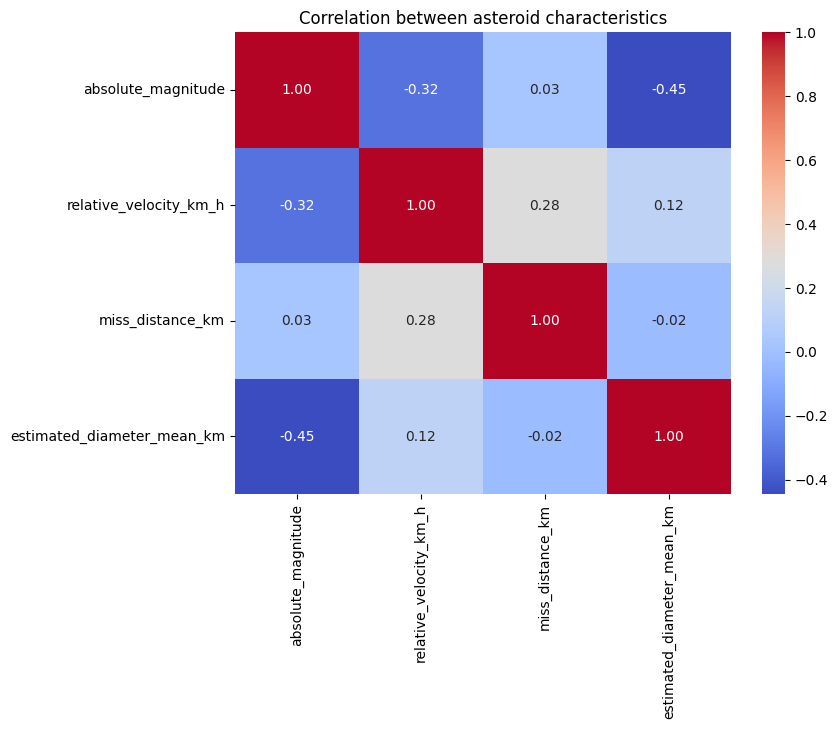

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(data=correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between asteroid characteristics')

plt.show()

Виявлено слабку негативну кореляцію між яскравістю астероїда та його оцінним діаметром. Це пов’язано з тим, що менше значення absolute magnitude відповідає яскравішому об’єкту. Також спостерігається слабка негативна кореляція між швидкістю та розміром астероїда.

6.Аналізуємо які астероїди повертаються

In [8]:
repeat_counts = (
    df.groupby(['neo_reference_id', 'name'])
    .size()
    .reset_index(name='approach_count')
    .sort_values('approach_count', ascending=False)
)

repeat_counts.head(20)

,neo_reference_id,name,approach_count
4558,54554706,(2025 US6),8
4447,3989284,(2020 BW12),7
3582,3825135,(2018 LV2),7
3670,3829424,(2018 RO5),7
3957,3840783,(2019 GE1),7
4460,3989355,(2020 CB),7
3271,3786458,(2017 UG),7
3564,3824978,(2018 KS),7
331,2469219,469219 Kamo`oalewa (2016 HO3),7
1143,3418110,(2008 NP3),7


In [9]:
top_asteroids = repeat_counts.head(5)['name']

top_data = df[df['name'].isin(top_asteroids)]

In [10]:
repeat_analysis = (df.groupby(['neo_reference_id', 'name'])
    .agg(
        approach_count=('date', 'count'),
        min_distance_km=('miss_distance_km', 'min'),
        mean_distance_km=('miss_distance_km', 'mean'),
        hazardous=('is_hazardous', 'max')
    )
    .reset_index()
    .sort_values('approach_count', ascending=False)
)

repeat_analysis.head(20)

,neo_reference_id,name,approach_count,min_distance_km,mean_distance_km,hazardous
4558,54554706,(2025 US6),8,1.366105e+05,2.095664e+05,False
4447,3989284,(2020 BW12),7,2.134743e+07,4.467689e+07,False
3582,3825135,(2018 LV2),7,3.876809e+07,4.157315e+07,False
3670,3829424,(2018 RO5),7,3.470313e+07,3.632578e+07,False
3957,3840783,(2019 GE1),7,2.542219e+07,2.992313e+07,False
4460,3989355,(2020 CB),7,2.533049e+07,3.503548e+07,False
3271,3786458,(2017 UG),7,4.471203e+07,5.144163e+07,False
3564,3824978,(2018 KS),7,3.560304e+07,3.790588e+07,False
331,2469219,469219 Kamo`oalewa (2016 HO3),7,1.792403e+07,2.258045e+07,False
1143,3418110,(2008 NP3),7,4.625894e+07,4.782530e+07,False


Виявлено астероїд, який повертався найчастіше у проміжку часу з 01.01.2023 по 16.05.2026 року

In [11]:
asteroid_name = '(2025 US6)'

df[df['name'] == asteroid_name][['date', 'miss_distance_km']
].sort_values('date')

,date,miss_distance_km
5307,2025-09-03,381125.227554
5369,2025-09-10,150841.656611
5428,2025-09-26,160725.797319
5512,2025-10-12,154424.091763
5585,2025-10-28,151088.537976
5645,2025-11-13,136610.515956
5669,2025-11-22,382219.655651
5755,2025-12-02,159495.549315


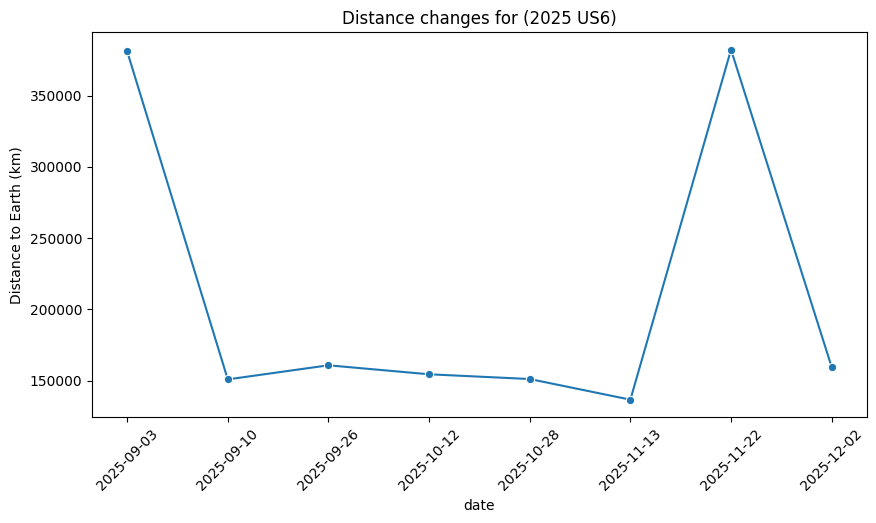

In [12]:
asteroid_name = '(2025 US6)'

asteroid_data = (df[df['name'] == asteroid_name].sort_values('date'))

plt.figure(figsize=(10,5))

sns.lineplot(data=asteroid_data, x='date', y='miss_distance_km', marker='o')

plt.xticks(rotation=45)
plt.title(f'Distance changes for {asteroid_name}')
plt.ylabel('Distance to Earth (km)')
plt.show()

Астероїд (2025 US6) повертався 8 разів і підходив на різну відстань до Землі. Найближча точка 13 листопада 2025 року - 136610 км

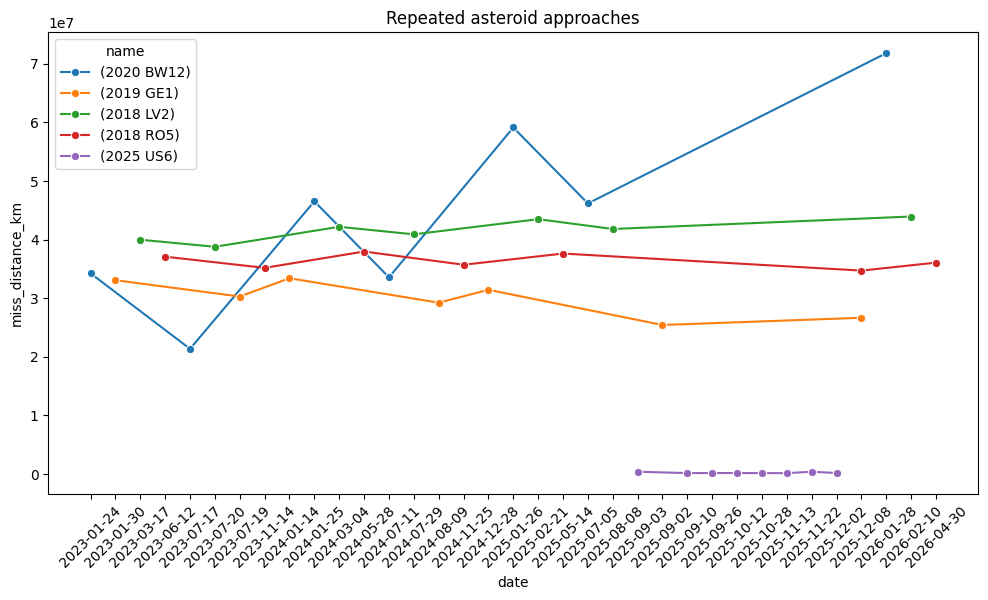

In [13]:
top_asteroids = (
    repeat_counts.head(5)['name']
)

top_data = df[df['name'].isin(top_asteroids)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=top_data,
    x='date',
    y='miss_distance_km',
    hue='name',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Repeated asteroid approaches')
plt.show()

Повторні зближення астероїдів можуть відбуватися на різній дистанції від Землі.

7. Фльтруємо тільки небезпечні

In [23]:
hazardous_df = df[df['is_hazardous']==True].copy()
hazardous_df

,date,neo_reference_id,name,is_hazardous,absolute_magnitude,relative_velocity_km_h,miss_distance_km,estimated_diameter_min_km,estimated_diameter_max_km,estimated_diameter_mean_km
4,2023-01-01,3767936,(2017 BQ93),True,20.60,86987.581071,1.538437e+07,0.201630,0.450858,0.326244
24,2023-01-03,2494690,494690 (2004 JQ1),True,20.10,122351.562675,7.362033e+07,0.253837,0.567597,0.410717
36,2023-01-07,3157028,(2003 MK4),True,20.86,52248.202443,1.667795e+07,0.178877,0.399982,0.289429
53,2023-01-12,3788037,(2017 UY5),True,18.79,41196.438257,2.460979e+07,0.464040,1.037624,0.750832
55,2023-01-12,2755919,755919 (2017 UY5),True,18.79,41196.438203,2.460979e+07,0.464040,1.037624,0.750832
...,...,...,...,...,...,...,...,...,...,...
6460,2026-05-13,2375103,375103 (2007 TD71),True,18.50,96064.547010,1.308489e+07,0.530341,1.185878,0.858109
6463,2026-05-13,3723888,(2015 NU2),True,20.91,58448.420586,6.943775e+07,0.174805,0.390877,0.282841
6479,2026-05-10,2326290,326290 Akhenaten (1998 HE3),True,21.83,38923.895099,1.100304e+07,0.114434,0.255882,0.185158
6484,2026-05-16,2141495,141495 (2002 EZ11),True,18.46,83071.167352,2.338661e+07,0.540200,1.207925,0.874063


In [24]:
cols = [
    'relative_velocity_km_h',
    'miss_distance_km',
    'estimated_diameter_mean_km'
]

hazardous_df[cols].describe()               #оцінюємо статистичні показники, для того щоб зрозуміти як розкид даних вплине на рейтинг

,relative_velocity_km_h,miss_distance_km,estimated_diameter_mean_km
count,689.000000,6.890000e+02,689.000000
mean,63416.868836,3.363533e+07,0.407049
std,28048.730906,2.216945e+07,0.305347
min,13623.582750,1.173362e+06,0.136629
25%,42697.188772,1.435230e+07,0.227794
50%,59576.379886,2.704668e+07,0.311561
75%,80734.626565,5.403193e+07,0.465096
max,152798.493945,7.464671e+07,3.232530


array([[<Axes: title={'center': 'relative_velocity_km_h'}>,
        <Axes: title={'center': 'miss_distance_km'}>],
       [<Axes: title={'center': 'estimated_diameter_mean_km'}>, <Axes: >]],
      dtype=object)

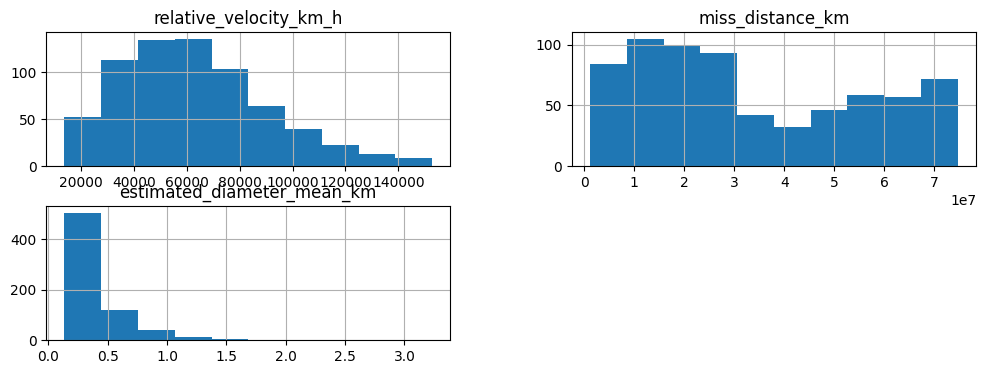

In [25]:
hazardous_df[cols].hist(figsize=(12,4))

75% потенційно небезпечних астероїдів мають середній оцінний діаметр до 0,5 км. Водночас у вибірці присутні кілька значно більших об’єктів, які впливають на середні значення.

8. Рахуємо кількість зближень серед потенційно небезпечних астероїдів

In [26]:
encounters = hazardous_df['neo_reference_id'].value_counts()
encounters

,count
neo_reference_id,
2138175,4
3591722,4
3350633,3
3255980,3
2612856,3
...,...
3549036,1
3618023,1
3549391,1


In [27]:
hazardous_df['encounters'] = hazardous_df['neo_reference_id'].map(encounters)                                   # додаємо колонку кількості повернеь

In [30]:
unique_asteroids = (hazardous_df.sort_values(by='miss_distance_km').drop_duplicates('neo_reference_id'))        #прибираємо дублікати
unique_asteroids

,date,neo_reference_id,name,is_hazardous,absolute_magnitude,relative_velocity_km_h,miss_distance_km,estimated_diameter_min_km,estimated_diameter_max_km,estimated_diameter_mean_km,encounters
1795,2023-10-17,3013045,(1998 HH49),True,21.37,53232.816011,1.173362e+06,0.141434,0.316257,0.228846,1
185,2023-02-03,2367789,367789 (2011 AG5),True,21.77,35705.682265,1.816903e+06,0.117640,0.263051,0.190346,1
4170,2024-12-04,54097969,(2020 XR),True,19.68,44314.474935,2.209274e+06,0.308003,0.688716,0.498359,1
5703,2025-11-25,3879725,(2019 UT6),True,21.90,45311.700737,2.387787e+06,0.110804,0.247765,0.179284,2
732,2023-04-26,3330155,(2006 HV5),True,19.41,62723.495185,2.419862e+06,0.348783,0.779902,0.564342,3
...,...,...,...,...,...,...,...,...,...,...,...
2407,2024-01-27,3785706,(2017 SY32),True,21.11,50980.193494,7.379597e+07,0.159424,0.356484,0.257954,1
5776,2025-12-10,2612012,612012 (1983 LC),True,19.47,118642.394518,7.395417e+07,0.339277,0.758647,0.548962,1
5771,2025-12-10,3005806,(1983 LC),True,19.45,118642.400637,7.395418e+07,0.342417,0.765667,0.554042,1
2032,2023-11-30,2480808,480808 (1994 XL1),True,20.64,102793.517628,7.445702e+07,0.197950,0.442629,0.320289,1


9. Розробляємо рейтинг для оцінки, виходячи із розміру, швидкості і наближення до Землі

In [31]:
rank_cols = [
    'relative_velocity_km_h',
    'miss_distance_km',
    'estimated_diameter_mean_km',
    'encounters'
]

In [33]:
for col in rank_cols:
    unique_asteroids[f'{col}_norm'] = (                                                #для приведення даних у співмірних формат застосовуємо нормалізацію за Min-Max методом
        (unique_asteroids[col] - unique_asteroids[col].min()) /
        (unique_asteroids[col].max() - unique_asteroids[col].min())
    )


In [34]:
unique_asteroids['distance_risk'] = (1 - unique_asteroids['miss_distance_km_norm'])       # для дистанції використовуємо обернене значення, оскільки менша відстань означає вищий ризик

In [35]:
unique_asteroids['risk_score'] = (                                                       # Для фінального рейтингу використано модель із рівними вагами показників, де швидкість, розмір, дистанція зближення
    unique_asteroids['relative_velocity_km_h_norm'] +                                    #та кількість повторних наближень мають однаковий вплив на risk score.
    unique_asteroids['estimated_diameter_mean_km_norm'] +
    unique_asteroids['distance_risk'] +
    unique_asteroids['encounters_norm']
) / 4

In [40]:
top_risk = unique_asteroids.sort_values(by ='risk_score', ascending=False)

top_risk = top_risk.round({'miss_distance_km': 0, 'relative_velocity_km_h': 0, 'estimated_diameter_mean_km': 3, 'risk_score': 3 })
top_risk[['name','miss_distance_km', 'relative_velocity_km_h', 'estimated_diameter_mean_km', 'encounters', 'risk_score']].head(10)

,name,miss_distance_km,relative_velocity_km_h,estimated_diameter_mean_km,encounters,risk_score
3328,415029 (2011 UL21),6641212.0,93176.0,2.802,1,0.588
1900,164121 (2003 YT1),8879791.0,83704.0,2.532,1,0.541
732,(2006 HV5),2419862.0,62723.0,0.564,3,0.532
3393,(2011 YJ28),18044829.0,50902.0,0.234,4,0.514
3305,504034 (2005 UJ159),10934841.0,114532.0,1.323,1,0.493
2889,(2015 TD323),19033904.0,120057.0,0.444,2,0.488
1835,302169 (2001 TD45),4874613.0,92443.0,0.430,2,0.484
5381,(2009 SG18),17071549.0,123601.0,1.258,1,0.483
671,4486 Mithra (1987 SB),24334530.0,48432.0,3.233,1,0.481
6050,276033 (2002 AJ129),13962598.0,135733.0,0.765,1,0.476


В результаті аналізу було виявлено 10 потенційно найбільш небезпечних астероїдів. Оскільки проєкт має дослідницький характер, для побудови risk score використано спрощену модель із рівним впливом показників без застосування спеціалізованих фізичних розрахунків.

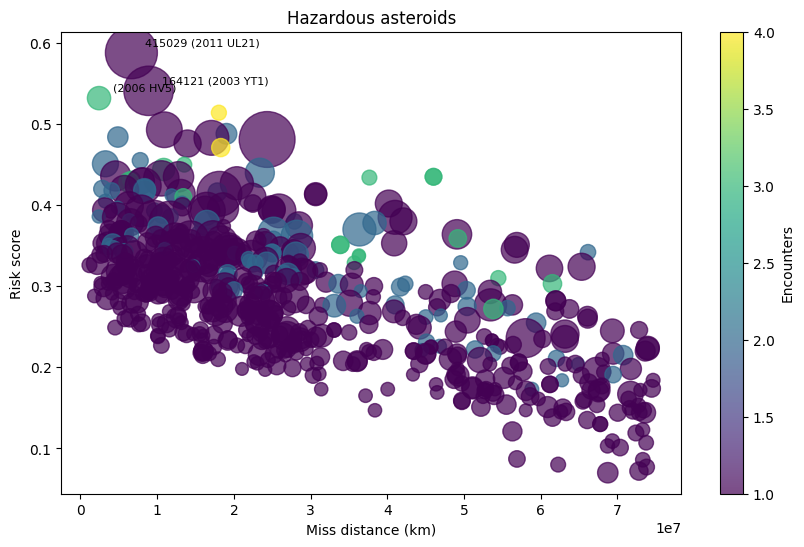

In [50]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    top_risk['miss_distance_km'],
    top_risk['risk_score'],
    s=top_risk['estimated_diameter_mean_km'] * 500,
    c=top_risk['encounters'],
    alpha=0.7
)

plt.xlabel('Miss distance (km)')
plt.ylabel('Risk score')
plt.title('Hazardous asteroids')

plt.colorbar(label='Encounters')
for i, row in top_risk.head(3).iterrows():
    plt.annotate(row['name'],
                 (row['miss_distance_km'], row['risk_score']),
                 xytext=(10, 5),
                 textcoords='offset points',
                 fontsize=8)

plt.show()

Графік демонструє, як у межах побудованої моделі змінюється risk score залежно від дистанції наближення астероїда до Землі.